In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os


In [2]:
DATASET_PATH = r'C:\Users\Egor\Desktop\study\diploma\project\dataset'
RESULT_PREPROCESSED_PATH = r'C:\Users\Egor\Desktop\study\diploma\project\dataset_preprocessed'
os.makedirs(RESULT_PREPROCESSED_PATH, exist_ok=True)


In [3]:

def reduce_mem_usage(df):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024 ** 2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024 ** 2
    print(f'Memory: {start_mem:.2f} Mb -> {end_mem:.2f} Mb ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df


def load_data(data_dir):
    print("Загрузка данных...")
    transactions = reduce_mem_usage(pd.read_csv(os.path.join(data_dir, "transactions_train.csv")))
    articles = reduce_mem_usage(pd.read_csv(os.path.join(data_dir, "articles.csv")))
    customers = reduce_mem_usage(pd.read_csv(os.path.join(data_dir, "customers.csv")))
    sample_sub = reduce_mem_usage(pd.read_csv(os.path.join(data_dir, "sample_submission.csv")))
    return transactions, articles, customers, sample_sub


In [4]:
transactions, articles, customers, sample_sub = load_data(DATASET_PATH)

Загрузка данных...
Memory: 1212.63 Mb -> 697.26 Mb (42.5% reduction)
Memory: 20.13 Mb -> 13.59 Mb (32.5% reduction)
Memory: 73.27 Mb -> 49.72 Mb (32.1% reduction)
Memory: 20.93 Mb -> 20.93 Mb (0.0% reduction)


In [5]:
print("Пропуски в articles:")
print(articles.isnull().sum())

print("Пропуски в customers:")
print(customers.isnull().sum())

print("Пропуски в transactions:")
print(transactions.isnull().sum())


Пропуски в articles:
article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64
Пропуски в customers:
customer_id                    0
FN         

In [6]:
for col in ['detail_desc']:
    if col in articles.columns:
        articles[col] = articles[col].fillna("Unknown")

customers['FN'] = customers['FN'].fillna(0).astype(int)
customers['postal_code'] = customers['postal_code'].fillna(customers['postal_code'].mode()[0])
customers['age'] = customers['age'].fillna(customers['age'].median()).astype(int)
active_mode = 0
customers['Active'] = customers['Active'].fillna(active_mode).astype(int)
customers['club_member_status'] = customers['club_member_status'].fillna('UNKNOWN')
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')

In [7]:
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
customers['age'] = customers['age'].astype(int)
transactions = transactions.drop_duplicates()
articles = articles.drop_duplicates(subset=['article_id'])
customers = customers.drop_duplicates(subset=['customer_id'])

In [8]:
print("После очистки:")
print(f"transactions: {transactions.shape}")
print(f"articles: {articles.shape}")
print(f"customers: {customers.shape}")

После очистки:
transactions: (28805603, 5)
articles: (105542, 25)
customers: (1371980, 7)


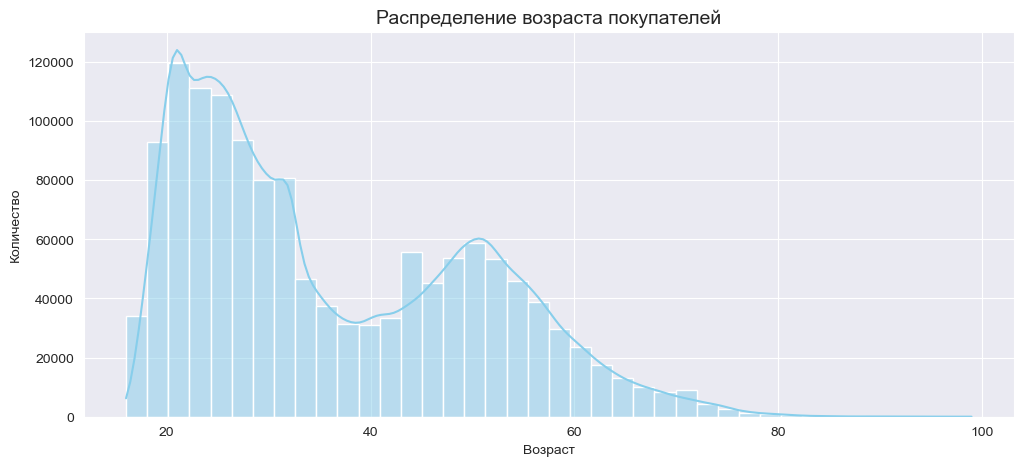

In [9]:
plt.figure(figsize=(12, 5))
sns.histplot(customers['age'], bins=40, kde=True, color='skyblue')
plt.title('Распределение возраста покупателей', fontsize=14)
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()
#Делаем вохрастные группы вместо возраста

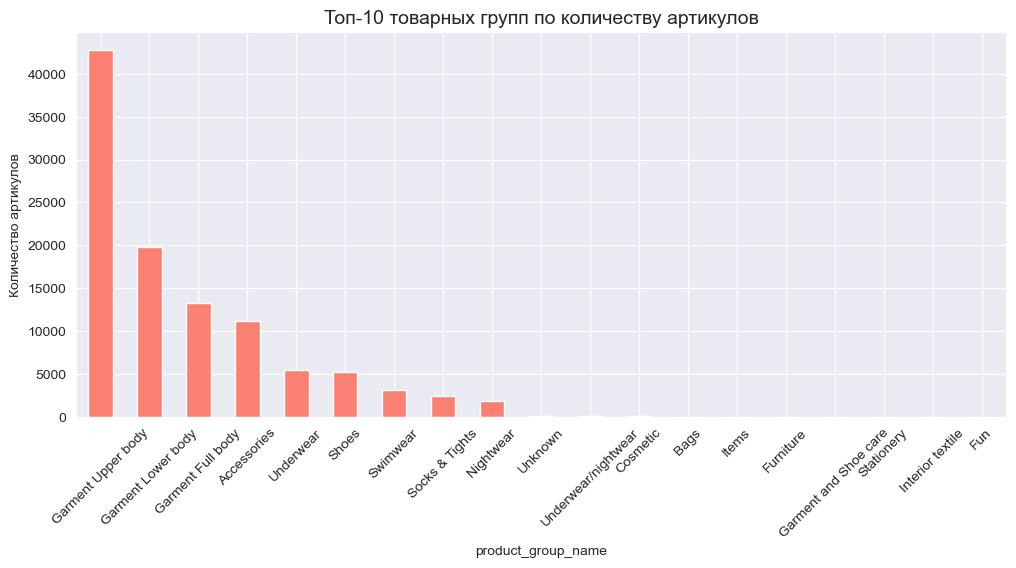

In [10]:
group_counts = articles['product_group_name'].value_counts()
plt.figure(figsize=(12, 5))
group_counts.plot(kind='bar', color='salmon')
plt.title('Топ-10 товарных групп по количеству артикулов', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Количество артикулов')
plt.show()

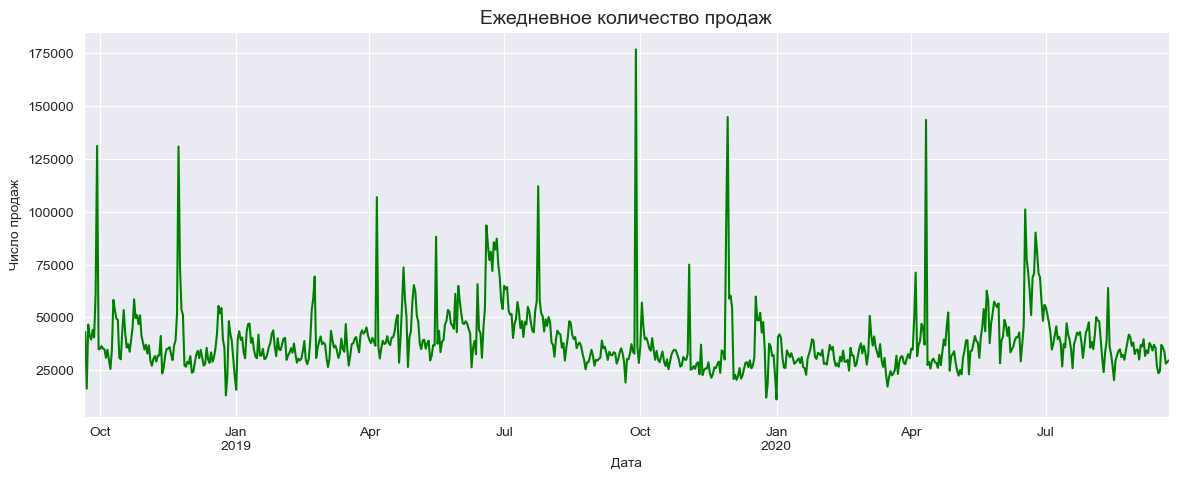

In [11]:
daily_sales = transactions.groupby('t_dat').size()
plt.figure(figsize=(14, 5))
daily_sales.plot(color='green')
plt.title('Ежедневное количество продаж', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Число продаж')
plt.show()
#Не прослеживаются зависимости, распределение +- равномерное

In [12]:
plt.figure(figsize=(12, 5))
sns.histplot(transactions['price'], bins=100, log_scale=True, kde=True, color='purple')
plt.title('Распределение цены за единицу (логарифмическая шкала)', fontsize=14)
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

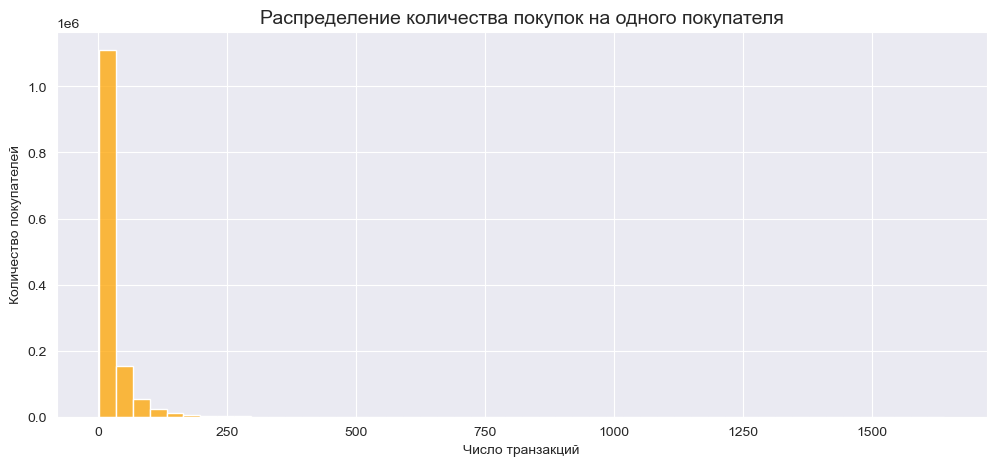

Среднее число покупок на клиента: 21.15
Медиана: 9.0
% клиентов с 1 покупкой: 10.9%


In [13]:
purchase_freq = transactions.groupby('customer_id').size()
plt.figure(figsize=(12, 5))
sns.histplot(purchase_freq, bins=50, log_scale=False, color='orange')
plt.title('Распределение количества покупок на одного покупателя', fontsize=14)
plt.xlabel('Число транзакций')
plt.ylabel('Количество покупателей')
plt.show()
print(f"Среднее число покупок на клиента: {purchase_freq.mean():.2f}")
print(f"Медиана: {purchase_freq.median()}")
print(f"% клиентов с 1 покупкой: { (purchase_freq == 1).mean() * 100:.1f}%")

In [14]:
### Добавление признаков

In [15]:
transactions['year'] = transactions['t_dat'].dt.year
transactions['month'] = transactions['t_dat'].dt.month
transactions['day'] = (transactions['t_dat'].max() - transactions['t_dat']).dt.days.astype('int16')
transactions['week'] = (transactions['day'] // 7).astype('int8')
transactions['day_of_week'] = transactions['t_dat'].dt.dayofweek
transactions['weekend'] = (transactions['day_of_week'] >= 5).astype(int)
transactions['season'] = transactions['month'].map({12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3})  # 0-winter,1-spring,2-summer,3-autumn

In [16]:
max_date = transactions['t_dat'].max()


rfm = transactions.groupby('customer_id').agg({
    't_dat': lambda x: (max_date - x.max()).days,  # Recency
    'customer_id': 'count',                        # Frequency
    'price': 'sum'                                 # Monetary
}).rename(columns={'t_dat': 'recency', 'customer_id': 'frequency', 'price': 'monetary'})
rfm['avg_basket'] = rfm['monetary'] / rfm['frequency']
rfm['recency_cat'] =  pd.qcut(rfm['recency'].fillna(rfm['recency'].median()),  q=5, labels=['rec_1','rec_2','rec_3','rec_4','rec_5'])
rfm['frequency_cat'] = pd.qcut(rfm['frequency'].fillna(0), 
                                     q=5, labels=['freq_1','freq_2','freq_3','freq_4','freq_5'])



rep = transactions.drop_duplicates(['customer_id', 'article_id', 't_dat']).groupby(
        ['customer_id', 'article_id']).size().reset_index(name='repeat_count')

user_stats = rep.groupby('customer_id')['repeat_count'].agg(['mean', 'max', 'std', 'count', 'sum']).reset_index()
user_stats.columns = ['customer_id', 'mean_repeat_by_cust', 'max_repeat_by_cust', 'std_repeat_by_cust', 'unique_items_by_cust', 'total_purchases_by_cust']
rfm = pd.merge(rfm, user_stats, on='customer_id', how='left')

item_stats = rep.groupby('article_id')['repeat_count'].agg(['mean', 'max', 'std', 'count', 'sum']).reset_index()
item_stats.columns = ['article_id', 'mean_repeat_by_item', 'max_repeat_by_item', 'std_repeat_by_item', 'unique_customers_by_item', 'total_sales_by_item']
item_stats['repeat_rate_by_item'] = (item_stats['total_sales_by_item'] - item_stats['unique_customers_by_item']) / item_stats['total_sales_by_item']
articles = pd.merge(articles, item_stats, on='article_id', how='left')


In [17]:
if False: #too much memory used
    for col in ['product_code', 'product_type_no', 'graphical_appearance_no',
                'colour_group_code', 'index_group_no', 'section_no', 'garment_group_no']:
        if col not in articles.columns:
            continue
        print(f'Processing {col}')
        tmp = transactions.merge(articles[[col, 'article_id']], on='article_id', how='left')
        tmp = tmp.dropna(subset=[col])
        last_purchase = tmp.groupby(['customer_id', col])['day'].min().reset_index()
        last_purchase.rename(columns={'day': f'last_{col}'}, inplace=True)
        customers = customers.merge(last_purchase[['customer_id', f'last_{col}']], on='customer_id', how='left')
        customers[f'last_{col}'] = customers[f'last_{col}'].fillna(9999).astype('int16')


In [18]:
weeks = 5
for w in range(weeks):
    cnt = transactions[transactions['week'] == w].groupby('article_id')['customer_id'].nunique().reset_index().rename(columns={'customer_id': f'article_id_week{w}_count'})
    articles = pd.merge(articles, cnt, on='article_id', how='left')
    articles[f'article_id_week{w}_count'] = articles[f'article_id_week{w}_count'].fillna(0).astype('int16')
articles[f'article_id_week0_ratio'] = (articles[f'article_id_week0_count'] / (articles[f'article_id_week1_count'] + 1e-5)).astype('float32')

In [19]:
days = 7
for d in range(days):
    cnt = transactions[transactions['day'] == d].groupby('article_id')['customer_id'].nunique().reset_index().rename(
        columns={'customer_id': f'article_id_day{d}_count'})
    articles = pd.merge(articles, cnt, on='article_id', how='left')
    articles[f'article_id_day{d}_count'] = articles[f'article_id_day{d}_count'].fillna(0).astype('int16')
articles[f'article_id_day0_ratio'] = (articles[f'article_id_day0_count'] / (articles[f'article_id_day1_count'] + 1e-5)).astype('float32')

In [20]:
for w in [999, 3, 0]:
    sub = transactions[transactions['week'] <= w] if w != 999 else transactions
    user_ch = sub.groupby('customer_id')['sales_channel_id'].agg(['mean', 'max']).reset_index()
    user_ch.columns = ['customer_id', f'mean_channel_{w}w_cust', f'max_channel_{w}w_cust']
    customers = pd.merge(customers, user_ch, on='customer_id', how='left')
    item_ch = sub.groupby('article_id')['sales_channel_id'].agg(['mean', 'max']).reset_index()
    item_ch.columns = ['article_id', f'mean_channel_{w}w_item', f'max_channel_{w}w_item']
    articles = pd.merge(articles, item_ch, on='article_id', how='left')
    
    for col in [f'mean_channel_{w}w_cust', f'max_channel_{w}w_cust']:
        customers[col] = customers[col].fillna(0)
    for col in  [f'mean_channel_{w}w_item', f'max_channel_{w}w_item']:
        articles[col] = articles[col].fillna(0)

In [21]:
article_popularity = transactions.groupby('article_id').size().rename('article_popularity')
article_avg_price = transactions.groupby('article_id')['price'].mean().rename('article_avg_sold_price')
article_mean_price = transactions.groupby('article_id')['price'].mean().rename('article_mean_sold_price')

articles = articles.merge(article_popularity, on='article_id', how='left')
articles = articles.merge(article_avg_price, on='article_id', how='left')
articles = articles.merge(article_mean_price, on='article_id', how='left')
articles['article_popularity'] = articles['article_popularity'].fillna(0)

recent = transactions[transactions['week'] < 4].groupby('article_id')['price'].mean().reset_index().rename(columns={'price': 'mean_price_4w'})
articles = pd.merge(articles, recent, on='article_id', how='left')
articles['article_avg_sold_price'] = articles['article_avg_sold_price'].fillna(transactions['price'].median())

articles['repeat_rate_by_item'] = (articles['total_sales_by_item'] - articles['unique_customers_by_item']) / articles['total_sales_by_item']

In [22]:
customers['age_group'] = pd.cut(customers['age'], bins=[0, 20, 30, 40, 50, 60, 100], labels=['<20', '20-29', '30-39', '40-49', '50-59', '60+'])


In [23]:
weekend_ratio = transactions.groupby('customer_id')['weekend'].mean().rename('weekend_purchase_ratio').fillna(0)
rfm = rfm.join(weekend_ratio, how='left')

In [24]:
trans_w_group = transactions.merge(articles[['article_id', 'product_group_name']], on='article_id', how='left')
top_group_per_cust = trans_w_group.groupby('customer_id')['product_group_name'].agg(lambda x: x.mode()[0] if len(x.mode())>0 else 'Unknown').rename('fav_product_group')
rfm = rfm.join(top_group_per_cust, how='left')

In [26]:
unique_articles = transactions.groupby('customer_id')['article_id'].nunique().rename('n_unique_articles')
rfm = rfm.join(unique_articles, how='left', on='customer_id')
rfm['unique_articles_cat'] = pd.qcut(
    rfm['n_unique_articles'].fillna(0),
    q=5,
    labels=['uniq_1', 'uniq_2', 'uniq_3', 'uniq_4', 'uniq_5'],
    duplicates='drop'
)
print("RFM таблица сформирована, shape:", rfm.shape)
print(rfm.head())

RFM таблица сформирована, shape: (1362281, 16)
                                         customer_id  recency  frequency  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       17         19   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...       76         78   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...        7         15   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...      471          2   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...       41         13   

   monetary  avg_basket recency_cat frequency_cat  mean_repeat_by_cust  \
0  0.543953    0.028629       rec_1        freq_4             1.000000   
1  2.412540    0.030930       rec_2        freq_5             1.218750   
2  0.606590    0.040439       rec_1        freq_4             1.071429   
3  0.060974    0.030487       rec_5        freq_1             1.000000   
4  0.469681    0.036129       rec_2        freq_3             1.083333   

   max_repeat_by_cust  std_repeat_by_cust  unique_i

In [27]:
customers = customers.merge(rfm, on='customer_id', how='left')

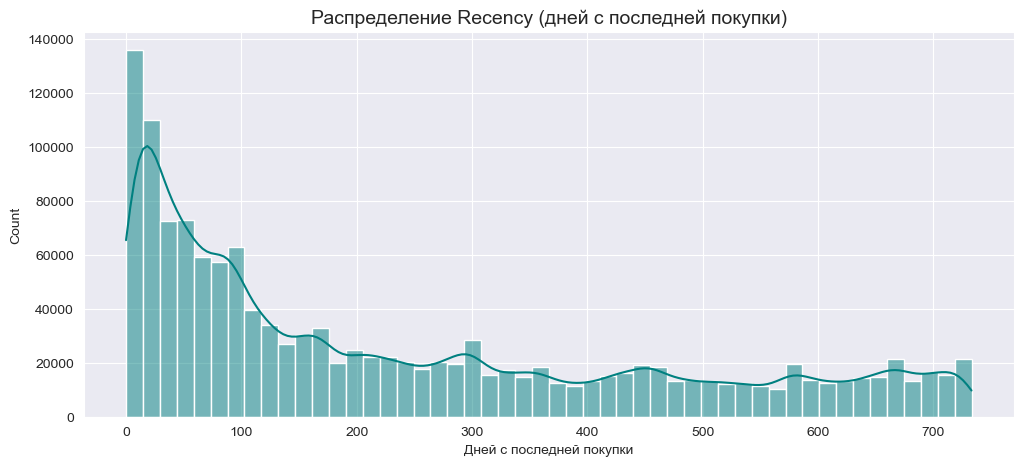

C:\Users\Egor\anaconda3\envs\torch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


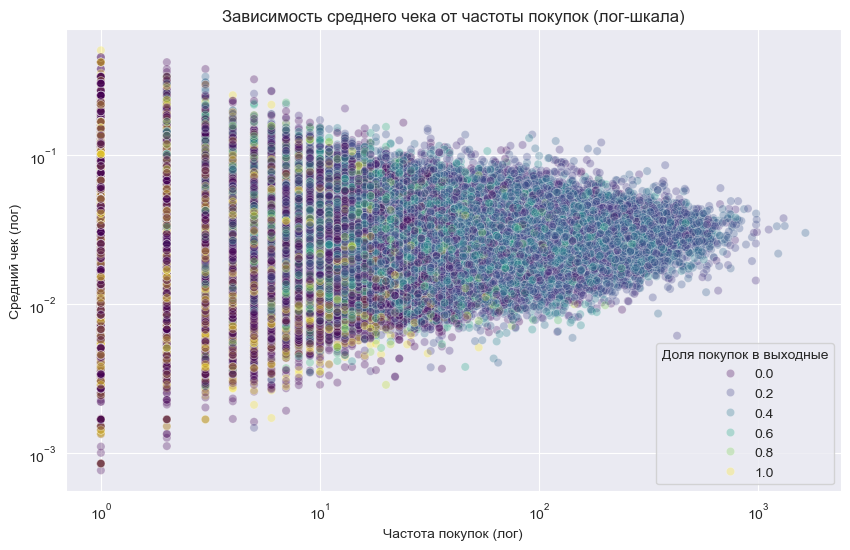

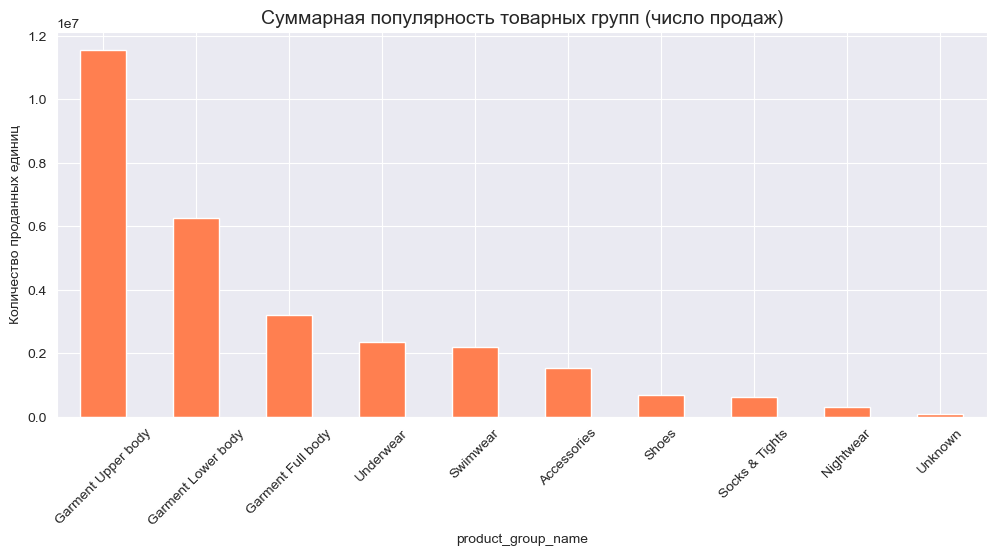

In [52]:
# График 6: Распределение recency
plt.figure(figsize=(12, 5))
sns.histplot(rfm['recency'], bins=50, kde=True, color='teal')
plt.title('Распределение Recency (дней с последней покупки)', fontsize=14)
plt.xlabel('Дней с последней покупки')
plt.show()

# График 7: Средний чек vs частота
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='frequency', y='avg_basket', alpha=0.3, hue='weekend_purchase_ratio', palette='viridis')
plt.xscale('log')
plt.yscale('log')
plt.title('Зависимость среднего чека от частоты покупок (лог-шкала)')
plt.xlabel('Частота покупок (лог)')
plt.ylabel('Средний чек (лог)')
plt.legend(title='Доля покупок в выходные')
plt.show()

# График 8: Популярность товарных групп (агрегированная)
top_products = articles.groupby('product_group_name')['article_popularity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
top_products.plot(kind='bar', color='coral')
plt.title('Суммарная популярность товарных групп (число продаж)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Количество проданных единиц')
plt.show()


In [28]:
articles.to_csv(os.path.join(RESULT_PREPROCESSED_PATH, "articles.csv"), index=False)
customers.to_csv(os.path.join(RESULT_PREPROCESSED_PATH, "customers.csv"), index=False)
transactions.to_csv(os.path.join(RESULT_PREPROCESSED_PATH, "transactions.csv"), index=False)
rfm.to_csv(os.path.join(RESULT_PREPROCESSED_PATH, "rfm_features.csv"))
print("Все файлы сохранены.")

Все файлы сохранены.
